## **IPF for fertility model, July 2025**
### To compute IPF solution for births and population for age, ethnicity and parity; data to come from ONS and *NewEthPop*

- Existing fertility model - implemented in Minos - takes ONS data *NewEthPop* data, expands to higher parity values using geometric series, then matches mean fertility rate per cell (i.e. each $(a, e, p)$ combination) to that in *NewEthPop*
- Not ideal because some data not very good or missing entirely, most importantly population by ethnicity, which means final fertility rate may not capture ethnicity dependence correctly
- Aim is to replace with better model that accounts for ethnicity, i.e. to compute fertility rate table as function of age, ethnicity and parity, i.e. $f(a, e, p)$
- For such a 3D table constructed using IPF, ideal constraints are three 2D cross-tabulations for each combination of variables; data sources in table below
- Methodology does **not** require any manual setting to reference values and instead preserves relationships between $(a, e, p)$ through the constraints and seed data given to IPF
- Important to note that constraints data are not available for every year that Minos will run for (i.e. 2020-2035 or so)
- However, used nearest-year methodology to get constraints for nearest available year; result is that some or most *relationships between variables* are represented for all years thus produced

 Dataset ID | Variables ($xyz$)$^{1}$ | Data source | File name(s)$^{2}$ |
| --- | --- | --- | --- |
| *Population ($P$)* |
| 1 | $xy \;(ae)$ | *NewEthPop* | ```Population2020_LEEDS2.csv```$^{3}$ |
| 2 | $yz \;(ep)$ | *NewEthPop* and ONS$^{4}$ | ```Population2020_LEEDS2.csv```$^{3}$ (for $e$) and <br> ```finalfertilityratesbyparity1934to2022.xlsx``` (for $p$) |
| 3 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |
| *Births ($b$)* |
| 4 | $xy \;(ae)$ | *NewEthPop*$^{5}$ | ```Fertility2020_LEEDS1_2.csv```$^{6}$ (for $f$) and <br> ```Population2020_LEEDS2.csv```$^{3}$ (for $P$) |
| 5 | $yz \;(ep)$ | ONS | ```20182022livebirthssexparity.xlsx```$^{7}$ |
| 6 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |

$^{1}$ Variables $x$ = age ($a$), $y$ = ethnicity ($e$) and $z$ = parity ($p$); also $f$ = fertility rate

$^{2}$ If multiple years available, data for 2020 given as example

$^{3}$ Via ```OutputData/Population``` folder

$^{4}$ Dataset not available directly; must compute 2D IPF solution, $P(e, p)$, using 1D constraints, $P(e)$ and $P(p)$

$^{5}$ Births by age and ethnicity not given directly, so necessary to calculate $b(a, e) = f(a, e) \cdot P(a, e)$

$^{6}$ Via ```InputData/Fertility``` folder

$^{7}$ Data given as total for 2018-2022, i.e. five years; must divide by five

### Primary functions - constraints data parsing

In [1]:
import os
from os.path import dirname as up
import sys

HOME = os.path.expanduser("~")
SYNTHPOP_PATH = os.path.join(HOME, "miniconda3/envs/synthpop_sandbox/lib/python3.11")  # Nasty workaround during development - Synthpop Sandbox was saved to Python 3.11 folder first (my fault - tried with 3.11 before finding conflict with Minos, which needs 3.9)
sys.path.append(SYNTHPOP_PATH)

import synthpop_sandbox
import pyipf

# All other setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import minos
from minos.utils import extend_series, get_nearest
from minos.RateTables import FertilityRateTable
from minos import fertility_utils as futils

MINOS_PATH = up(os.path.dirname(minos.__file__))
PERSISTENT_DATA = os.path.join(MINOS_PATH, 'persistent_data',)
DATA_PATH = os.path.join(MINOS_PATH, 'data')
FERTILITY_PATH = os.path.join(DATA_PATH, 'fertility')
BIRTHS_PATH = os.path.join(FERTILITY_PATH, 'births')
POP_PATH = os.path.join(FERTILITY_PATH, 'population')
SYNTHPOP_PATH = os.path.join(DATA_PATH, 'scaled_gb_US')
NEP_DATA_PATH = os.path.join(up(MINOS_PATH), 'Leeds2Projections', '2DataArchive')

TFR_PROJECTIONS_DEFAULT = os.path.join(PERSISTENT_DATA, 'fertility_reference', 'Figure_3__The_2022-based.csv')
ASFR_PROJECTIONS_DEFAULT = os.path.join(PERSISTENT_DATA, 'fertility_reference', 'Figure_4__Fertility_rates_for_women.csv')


# HR 02/08/25 To get nearest year in NewEthpop data
def get_nearest_newethpop(year):
    pop_path = os.path.join(NEP_DATA_PATH, 'OutputData', 'Population')
    pop_years = [int(f.lstrip('Population').split('_')[0]) for f in os.listdir(os.path.join(pop_path)) if f.endswith('csv')]
    nearest_newethpop = get_nearest(pop_years, year)
    return nearest_newethpop

# HR 02/08/25 To get nearest year in ONS pop-births data
def get_nearest_ons(year):
    fert_ons = FertilityRateTable.parse_parity_ons()
    fert_years = fert_ons['year'].unique()
    nearest_ons = get_nearest(fert_years, year)
    return nearest_ons

# HR 30/07/25 For normalising constraints to reference totals
# Must use ONS fertility data, as common to population and births constraints calculations
def normalise_to_reference(to_be_normalised, reference_dataset):
    _sum = int(reference_dataset.sum().sum())
    normalised = []
    for dataset in to_be_normalised:
        dataset = dataset * _sum / dataset.sum().sum()
        normalised.append(dataset)
    return normalised

def get_synthpop_data(path=SYNTHPOP_PATH, pc=1):
    sp_file = '2019_US_cohort.csv'
    sp_full = os.path.join(path, str(pc) + 'pc', sp_file)
    sp = pd.read_csv(sp_full)
    return sp

# HR 05/08/25 Get ONS TFR projections
def get_tfr_projections(file=TFR_PROJECTIONS_DEFAULT):
    data = pd.read_csv(file, header=6).set_index('Year')[['2022-based principal projection']]
    data.columns = ['tfr']
    return data

# HR 07/08/25 Get ONS ASFR projections
def get_asfr_projections(file=ASFR_PROJECTIONS_DEFAULT):
    data = pd.read_csv(file, header=6).set_index('Year')
    return data

# HR 13/08/25 Check fertility data folders exist and create if not
def check_fertility_folders():
    if not os.path.exists(BIRTHS_PATH):
        os.makedirs(BIRTHS_PATH)
        print('Births data path not found; created it!')
    if not os.path.exists(POP_PATH):
        os.makedirs(POP_PATH)
        print('Population data path not found; created it!')


# Any parameters for constraints data and IPF input
year = 2020

AGE_RANGE_DEFAULT = (15, 44)
PARITY_MAX = 9

ZERO_VALUE = 1e-4
TRUNC_VALUE = 1
FILL_THRESHOLD = ZERO_VALUE / 10
FILL_VALUE = 1e-8
normaliser = 'nep'
# normaliser = 'ons'

VARS_3D = ['age', 'eth_group', 'nkids_ind']
VARS_2D = ['age', 'eth_group']

eth_map = futils.get_ethnicity_map()
headline_cols = ['LAD.code', 'ETH.group']  # Headers to retain

# Categories for labelling
cats = {'age': [el for el in range(AGE_RANGE_DEFAULT[0], AGE_RANGE_DEFAULT[1] + 1)],
        'eth_group': sorted([el.lower() for el in set(eth_map.values())]),
        'nkids_ind': [el for el in range(PARITY_MAX + 1)],
       }

# Parameters for PyIPF algorithm
pyipf_params = {'tol_convg': 1e-6,
                'convg': 'relative',
                'pbar': True,
               }

### Secondary functions - rate table construction and application to populations

In [2]:
# HR 06/08/25 Automate fertility rate table creation
def create_fertility_table(births_table, pop_table, scale_factor=1, zero_value=ZERO_VALUE, trunc_value=TRUNC_VALUE):

    # Apply scale factor; important that this comes before fertility rate table calculation
    if scale_factor != 1:
        births_table *= scale_factor
    rt = births_table['births'] / pop_table['population']
    rt = rt.to_frame(name='fertility')
    
    # Get conditions for correcting zero and very large fertility values, then correct
    zerof_mask = (rt < zero_value)
    trunc_mask = (rt > trunc_value)
    rt[zerof_mask] = 0
    rt[trunc_mask] = 1

    return rt

# HR 06/08/25 Get reference metric for specified year
# Initially intended for projected values for fitting at runtime
def get_reference_value(reference_metric, reference_year):
    if reference_metric == 'tfr':
        ref_val = get_tfr_projections().loc[reference_year].values[0]
    if reference_metric == 'asfr':
        ref_val = get_asfr_projections().loc[reference_year]
    # elif reference_metrics == 'gfr:
    #     ref_val = <SOMETHING>
    else:
        print('Reference metric not available for "{}"; returning None'.format(reference_metric))
        return
    return ref_val

# HR 06/08/25 To match fertility rate (by applying rate table to population) to reference value iteratively
def match_rate_table(pop, births_table, pop_table, cats, reference_metric, reference_value, tol=0.005, max_it=20):

    metric_functions = {'tfr': futils.get_tfr,
                        'gfr': futils.get_gfr,
                        'cbr': futils.get_cbr,
                        # 'sma': futils.get_sma,  # Not working - probably a direction-of-effect problem
                       }
    metric_method = metric_functions[reference_metric]

    # Get initial values before iteration
    bt = births_table.copy()
    pt = pop_table.copy()
    
    rate_table = create_fertility_table(bt, pt)
    pop = apply_fertility_model(pop, rate_table)
    metric_value = metric_method(pop)
    print('{} = {}, ref = {}'.format(reference_metric, metric_value, reference_value))
    conv = abs(metric_value - reference_value) / reference_value
    
    metric_history = [metric_value]
    conv_history = [conv]

    it = 0
    while conv > tol and it < max_it:
        scale_factor = reference_value / metric_value
        print(scale_factor)
        rate_table = create_fertility_table(bt, pt, scale_factor=scale_factor)
        pop = apply_fertility_model(pop, rate_table)
        metric_value = metric_method(pop)
        print('{} = {}, ref = {}'.format(reference_metric, metric_value, reference_value))
        conv = abs(metric_value - reference_value) / reference_value

        metric_history.append(metric_value)
        conv_history.append(conv)
        it += 1

    if it <= max_it:
        print('Converged!')
    else:
        print('Not converged, max. iterations reached')
    return rate_table, metric_history, conv_history

# HR 06/08/25 Simple RNG fertility calculator
# Acts on Minos-type population dataframe and computes newborns
# 2D (a, e) and 3D (a, e, p) versions differentiated by _vars parameter
def apply_fertility_model(pop, rate_table, age_range=AGE_RANGE_DEFAULT):

    # Convert rate table to dict for readability
    _vars = list(rate_table.index.names)
    rt_dict = rate_table['fertility'].to_dict()
    
    # Get women so all fertility variables can be added easily by index
    women = pop.loc[(pop['sex'] == 'Female') & (pop['age'].between(*age_range))]
    
    # Add tuple column, map fertility rates and get newborns
    pop.loc[women.index, 'fertcat'] = pop[_vars].apply(tuple, axis=1)
    pop.loc[women.index, 'rnd'] = np.random.rand(len(women))
    pop.loc[women.index, 'fertval'] = pop['fertcat'].map(rt_dict)
    pop.loc[women.index, 'nnewborn'] = pop['fertval'] > pop['rnd']

    # Drop temporary columns
    pop.drop(columns=['fertcat', 'rnd', 'fertval'])
    return pop

### Getting the constraints data

In [23]:
def get_constraints_data(year, age_range = AGE_RANGE_DEFAULT):

    fert_ons = FertilityRateTable.parse_parity_ons()
    year_nearest_ons = get_nearest_ons(year)
    year_nearest_newethpop = get_nearest_newethpop(year)

    
    ### DATASET 1 ###
    filename_1 = 'Population' + str(year_nearest_newethpop) + '_LEEDS2.csv'
    ageeth_p = pd.read_csv(os.path.join(NEP_DATA_PATH, 'OutputData', 'Population', filename_1))
        
    # Tidy pop data
    dfp = ageeth_p.T
    dfp = dfp.loc[~dfp.index.str.startswith('M')]
    dfp = dfp.loc[~dfp.index.astype(str).isin(headline_cols)]
    dfp = dfp.loc[dfp.index.str.startswith('F')]
    dfp.index = dfp.index.str.rstrip('p').str.lstrip('F').astype(int)
    tidy_p = pd.concat([ageeth_p[headline_cols], dfp.loc[age_range[0]:age_range[1]].T], axis=1)
    
    # Subset for England and Wales - all ONS data is also EW only
    tidy_p = tidy_p.loc[tidy_p['LAD.code'].str[0].isin(('E', 'W'))]
    
    # Get population by age-ethnicity
    tidy_p['ethnicity'] = tidy_p['ETH.group'].map(eth_map)
    tidy_p = tidy_p.set_index(headline_cols)
    xy_p = tidy_p.groupby('ethnicity').sum().T
    xy_p.columns = [el.lower() for el in xy_p.columns]


    ### DATASET 2 ###
    # 1. Get population by ethnicity
    margin_e = tidy_p.groupby('ethnicity').sum().sum(axis=1).to_list()
    
    # 2. Get population by parity
    # HR 29/07/25 Get ONS data for population by age and parity 
    fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'p1', 'p2', 'p3', 'p4', 'p5']].set_index('age')
    
    margin_p = fert_ym.sum()
    margin_p = extend_series(margin_p.to_list(), PARITY_MAX - len(margin_p) + 2)
    corrector = sum(margin_e) / sum(margin_p)
    margin_p = [el*corrector for el in margin_p]

    # 3. Get population by ethnicity-parity using IPF
    dims = (len(margin_e), len(margin_p))
    m = np.ones(dims)
    marginals = [margin_p, margin_e]
    print(marginals)
    result = pyipf.ipf(m, marginals, **pyipf_params)

    # Final format
    yz_p = pd.DataFrame(result)
    yz_p.index = [el.lower() for el in xy_p.columns]


    ### DATASET 3 ###
    # Get population by age-parity
    val = fert_ym.loc[age_range[0]:age_range[1]]
    valx = val.apply(lambda x: extend_series(x.to_list(), PARITY_MAX - val.shape[1] + 2), axis=1)
    valx = pd.DataFrame(valx.to_list())
    valx.index = val.index
    xz_p = valx


    ### DATASET 4 ###
    filename_4 = 'Fertility' + str(year_nearest_newethpop) + '_LEEDS1_2.csv'
    ageeth_f = pd.read_csv(os.path.join(NEP_DATA_PATH, 'InputData', 'Fertility', filename_4))
    
    # Tidy fertility data
    dff = ageeth_f.T
    dff = dff.loc[~dff.index.str.startswith('M')]
    dff = dff.loc[~dff.index.astype(str).isin(headline_cols)]
    dff = dff.loc[dff.index.str.startswith('F')]
    dff.index = dff.index.str.rstrip('p').str.lstrip('F').str.split('.').str[-1].astype(int) - 1
    tidy_f = pd.concat([ageeth_f[headline_cols], dff.loc[age_range[0]:age_range[1]].T], axis=1)
    
    # Subset for England and Wales - all ONS data is also EW only
    tidy_f = tidy_f.loc[tidy_f['LAD.code'].str[0].isin(('E', 'W'))]
    
    # Get fertility rate by births by age-ethnicity
    tidy_f['ethnicity'] = tidy_f['ETH.group'].map(eth_map)
    tidy_f = tidy_f.set_index(headline_cols)
    
    # Multiply fertility rate by population to get births by age-ethnicity
    tidy_b = tidy_p.loc[:, tidy_p.columns != 'ethnicity'] * tidy_f.loc[:, tidy_f.columns != 'ethnicity']
    tidy_b['ethnicity'] = tidy_b.reset_index()['ETH.group'].map(eth_map).to_list()  # Must add to_list at end as resetting index causes index mismatch
    xy_b = tidy_b.groupby('ethnicity').sum().T
    xy_b.columns = [el.lower() for el in xy_b.columns]


    ### DATASET 5 ###
    # Get birth by ethnicity-parity
    ETH_FILE = "20182022livebirthssexparity.xlsx"
    ETH_FULL = os.path.join(PERSISTENT_DATA, ETH_FILE)
    
    eth_raw = pd.read_excel(ETH_FULL,
                            sheet_name='2',
                            header=5,
                           )
    
    ethnicity = ['asian', 'black', 'asian', 'black', 'black', 'asian', 'mixed', 'not stated', 'other', 'asian', 'white', 'white']
    eth_raw.insert(0, 'ethnicity', ethnicity)
    eth_raw.drop(columns=eth_raw.columns[1], inplace=True)
    eth_raw = eth_raw.loc[eth_raw.ethnicity != 'not stated']
    
    eth_t = eth_raw.groupby('ethnicity').sum().T
    eth_tp = eth_t.loc[eth_t.index.str.split(' ').str[0].isin(('First', 'Second', 'Third'))].copy()
    eth_tp['parity'] = eth_tp.index.str[0].map({'F': 0, 'S': 1, 'T': 2})
    
    eth_tpg = eth_tp.groupby('parity').sum().T
    eth_ext = eth_tpg.apply(lambda x: extend_series(x.to_list(), PARITY_MAX - eth_tpg.shape[1] + 2), axis=1)
    eth_done = pd.DataFrame(eth_ext.to_list())
    eth_done.index = eth_ext.index
    yz_b = eth_done / 5  # Accounts for data being for five-year period, 2018-2022


    ### DATASET 6 ###
    fert_ym = fert_ons.loc[(fert_ons['year'] == year_nearest_ons), ['age', 'b1', 'b2', 'b3', 'b4', 'b5']].set_index('age')

    val = fert_ym.loc[age_range[0]:age_range[1]]
    valx = val.apply(lambda x: extend_series(x.to_list(), PARITY_MAX - val.shape[1] + 2), axis=1)
    valx = pd.DataFrame(valx.to_list())
    valx.index = val.index
    xz_b = valx

    return xy_p, yz_p, xz_p, xy_b, yz_b, xz_b

## IPF solutions (births and population must be done separately)

In [4]:
names = list(cats.keys())
categories = list(cats.values())

# HR 13/08/25 Rolling IPF solution into a function
def get_ipf_solutions(year, normaliser='nep', recalculate=False):

    # First try and load from file, if present
    births_fullpath = os.path.join(BIRTHS_PATH, 'births_' + str(year) + '.csv')
    pop_fullpath = os.path.join(POP_PATH, 'population_' + str(year) + '.csv')

    if not recalculate:
        try:
            df_b = pd.read_csv(births_fullpath, index_col=names)
            df_p = pd.read_csv(pop_fullpath, index_col=names)
            print('Loaded cached data from file for year {}'.format(year))
            return df_b, df_p
        except Exception as e:
            print(e)
            print('Cached data not found; computing and caching for year {}'.format(year))

    # 1. Fill structural (i.e. real) zeroes with small value to prevent IPF having a nervous breakdown
    xy_p, yz_p, xz_p, xy_b, yz_b, xz_b = get_constraints_data(year)
    constraints = [xy_p, yz_p, xz_p, xy_b, yz_b, xz_b]
    for c in constraints:
        c[c < FILL_THRESHOLD] = FILL_VALUE
    
    # 2. Normalise all constraints to reference dataset, either ONS or NEP; must do this otherwise PyIPF complains
    if normaliser == 'nep':
        xy_p_corr, yz_p_corr, xz_p_corr = normalise_to_reference([xy_p, yz_p, xz_p], xy_p)
        xy_b_corr, yz_b_corr, xz_b_corr = normalise_to_reference([xy_b, yz_b, xz_b], xy_b)
    elif normaliser == 'ons':
        xy_p_corr, yz_p_corr, xz_p_corr = normalise_to_reference([xy_p, yz_p, xz_p], xz_p)
        xy_b_corr, yz_b_corr, xz_b_corr = normalise_to_reference([xy_b, yz_b, xz_b], xz_b)
    
    ### BIRTHS ###
    m0 = yz_b_corr.to_numpy()  # yz
    m1 = xz_b_corr.to_numpy()  # xz
    m2 = xy_b_corr.to_numpy()  # xy
    marginals_births = [m0, m1, m2]
    seed_b = np.stack([m1]*len(cats['eth_group']), axis=1)  # Seed table, retains zeroes
    result_b = pyipf.ipf(seed_b, marginals_births, **pyipf_params)
    
    ### POPULATION ###
    m3 = yz_p_corr.to_numpy()  # yz
    m4 = xz_p_corr.to_numpy()  # xz
    m5 = xy_p_corr.to_numpy()  # xy
    marginals_pop = [m3, m4, m5]
    seed_p = np.stack([m4]*len(cats['eth_group']), axis=1)  # Seed table, retains zeroes
    result_p = pyipf.ipf(seed_p, marginals_pop, **pyipf_params)

    # Convert to dataframes and dump
    index = pd.MultiIndex.from_product(categories, names=names)
    df_b = pd.DataFrame({'births': result_b.flatten()}, index=index)
    df_p = pd.DataFrame({'population': result_p.flatten()}, index=index)

    # Check/create data folders and dump data
    check_fertility_folders()
    df_b.to_csv(births_fullpath)
    df_p.to_csv(pop_fullpath)
    
    return df_b, df_p

## Analysis section

### 1. Some basic validation of IPF output (GFR, as easily calculated from results)

In [5]:
# # Compare competing constraint sets, i.e. ONS vs. NewEthPop
# xy_p, yz_p, xz_p, xy_b, yz_b, xz_b = get_constraints_data(year)

# print(xy_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=1))

# print(xz_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=0))

# print(xy_b_corr.sum(axis=1))
# print(xz_b_corr.sum(axis=1))

# print(xy_p_corr.sum(axis=0))
# print(yz_p_corr.sum(axis=1))

# print(xz_p_corr.sum(axis=0))
# print(yz_p_corr.sum(axis=0))

# print(xy_p_corr.sum(axis=1))
# print(xz_p_corr.sum(axis=1))


# HR 14/08/25 Get naive GFR from IPF results, i.e. GFR = births / population
def get_simple_gfr(births, population):
    gfr = 1000 * births.sum().sum() / population.sum().sum()
    return gfr

# HR 14/08/25 Get effect of correcting fertility rate table in terms of births and population
def get_correction_effects(births, population, show_results=True):

    # Get fertility rate tables
    fert = create_fertility_table(births, population)
    
    # Get masks
    zerof_mask = fert.loc[fert['fertility'] == 0].index
    trunc_mask = fert.loc[fert['fertility'] == 1].index
    
    # Get corresponding population size
    zerof_pop = 100 * population.loc[zerof_mask].sum() / population.sum()
    trunc_pop = 100 * population.loc[trunc_mask].sum() / population.sum()
    
    # Get corresponding population size
    zerof_births = 100 * births.loc[zerof_mask].sum() / births.sum()
    trunc_births = 100 * births.loc[trunc_mask].sum() / births.sum()
    
    if not show_results:
        return zerof_pop, trunc_pop, zerof_b, trunc_b

    print('### Calculating zero and unity cells in fertility rate table ###')
    print('Zero cells in result: {}'.format(len(zerof_mask)))
    print('Unity cells in result: {}'.format(len(trunc_mask)))
    
    print('Proportion of population with zero fertility rate (i.e. f = 0): {0:.4g}%'.format(zerof_pop[0]))
    print('Proportion of population with truncated fertility rate (i.e. f > 1 before correction): {0:.4g}%'.format(trunc_pop[0]))
    
    print('Proportion of births with zero fertility rate (i.e. f = 0): {0:.4g}%'.format(zerof_births[0]))
    print('Proportion of births with truncated fertility rate (i.e. f > 1 before correction): {0:.4g}%'.format(trunc_births[0]))
    
    return zerof_pop, trunc_pop, zerof_births, trunc_births


# Testing get_ipf_solutions function
y = 2020
births_3d, pop_3d = get_ipf_solutions(year=y)

# Sum over parity to create 2D version, i.e. (a, e) only
births_2d = births_3d.groupby(level=['age', 'eth_group']).sum()
pop_2d = pop_3d.groupby(level=['age', 'eth_group']).sum()

# Get GFR for validation
gfr_3d = get_simple_gfr(births_3d, pop_3d)
gfr_2d = get_simple_gfr(births_2d, pop_2d)

# Compare results - should be identical
print('### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###')
print("GFR(a, e, p) = {0:.6g}".format(gfr_3d))
print("GFR(a, e)    = {0:.6g}".format(gfr_2d))

Loaded cached data from file for year 2020
### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###
GFR(a, e, p) = 53.2243
GFR(a, e)    = 53.2243


### 2. Quantify effect of correcting 0/1 values in terms of births and population

In [6]:
# Get fertility rate tables
f_3d = create_fertility_table(births_3d.copy(), pop_3d.copy())
f_2d = create_fertility_table(births_2d.copy(), pop_2d.copy())

# See whether truncating/correcting fertility results affect GFR
get_correction_effects(births_3d, pop_3d)
get_correction_effects(births_2d, pop_2d)

### Calculating zero and unity cells in fertility rate table ###
Zero cells in result: 48
Unity cells in result: 199
Proportion of population with zero fertility rate (i.e. f = 0): 6.02e-05%
Proportion of population with truncated fertility rate (i.e. f > 1 before correction): 0.003186%
Proportion of births with zero fertility rate (i.e. f = 0): 4.565e-11%
Proportion of births with truncated fertility rate (i.e. f > 1 before correction): 0.08449%
### Calculating zero and unity cells in fertility rate table ###
Zero cells in result: 0
Unity cells in result: 0
Proportion of population with zero fertility rate (i.e. f = 0): 0%
Proportion of population with truncated fertility rate (i.e. f > 1 before correction): 0%
Proportion of births with zero fertility rate (i.e. f = 0): 0%
Proportion of births with truncated fertility rate (i.e. f > 1 before correction): 0%


(population    0.0
 dtype: float64,
 population    0.0
 dtype: float64,
 births    0.0
 dtype: float64,
 births    0.0
 dtype: float64)

## Applying fertility rate table to microsim input population

### 1. Basic validation - comparing fertility rates using 2D and 3D rate tables to reference values

In [7]:
# Get 1% synthpop and tidy up (uses Minos functionality later so must be in that format)
sp20 = get_synthpop_data(pc=1)
sp20['alive'] = 'alive'
sp20['eth_group'] = sp20['ethnicity'].map(eth_map).str.lower()

# Get crosstab for tabular calculation and grouped by (a, e, p) with zeroes retained - not finished tabular method as very fiddly
# sp20ct = pd.crosstab([sp20['age'], sp20['eth_group']], sp20['nkids_ind'])
# sp20gb = sp20.groupby(VARS_3D).size().unstack(fill_value=0).stack()  # Without unstack/stack, empty cases are excluded, e.g. 16/Asian/1

### 3D FERTILITY
sp_3d = apply_fertility_model(sp20.copy(), f_3d)
print("GFR (3D) = {} per 1,000".format(futils.get_gfr(sp_3d)))

### 2D FERTILITY
sp_2d = apply_fertility_model(sp20.copy(), f_2d)
print("GFR (2D) = {} per 1,000".format(futils.get_gfr(sp_2d)))

tfr_ref = futils.get_tfr(sp20)
tfr_actual = get_tfr_projections().loc[year].values[0]
print('TFR (ref): {}\nTFR (actual): {}'.format(tfr_ref, tfr_actual))

GFR (3D) = 49.41489244589269 per 1,000
GFR (2D) = 50.133204165657546 per 1,000
TFR (ref): 1.6850560111495068
TFR (actual): 1.51


### 2. Testing fertility rate adjustment - iteratively setting actual fertility rate to reference value

In [8]:
ref_val = get_tfr_projections().loc[year].values[0]
matched = match_rate_table(sp20, births_3d, pop_3d, cats, 'tfr', ref_val)

tfr = 1.5247727949916876, ref = 1.51
0.9903114778541362
tfr = 1.4828444596143846, ref = 1.51
1.0183131414826052
tfr = 1.5072296354509267, ref = 1.51
Converged!


## Visualisation of results: comparison of IPF output with reference GFR data

ipfn converged: convergence_rate below threshold


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

ipfn converged: convergence_rate below threshold


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

ipfn converged: convergence_rate below threshold


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

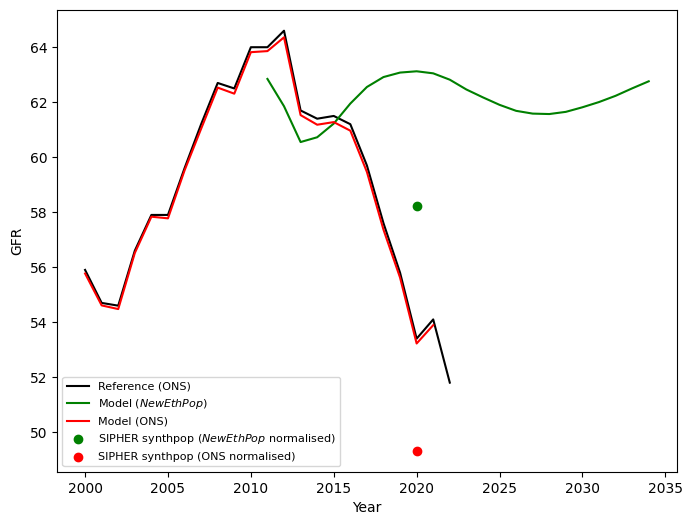

In [9]:
# Automate GFR calculations for NEP and ONS to show differences in naive GFR
nep_years = range(2011, 2035)
ons_years = range(2000, 2022)

model_data_nep = {}
for y in nep_years:
    by, py = get_ipf_solutions(year=y, normaliser='nep', recalculate=True)
    model_data_nep[y] = get_simple_gfr(by, py)
model_data_nep = pd.Series(model_data_nep)

model_data_ons = {}
for y in ons_years:
    by, py = get_ipf_solutions(year=y, normaliser='ons', recalculate=True)
    model_data_ons[y] = get_simple_gfr(by, py)
model_data_ons = pd.Series(model_data_ons)

# Add some points for the SIPHER synthpop (2020) for comparison
y = 2020

result_nep = get_ipf_solutions(year=y, normaliser='nep', recalculate=True)
rt_nep = create_fertility_table(*result_nep)
pop_nep = apply_fertility_model(sp20, rt_nep)
synthpop_result_nep = {y: futils.get_gfr(pop_nep)}

result_ons = get_ipf_solutions(year=y, normaliser='ons', recalculate=True)
rt_ons = create_fertility_table(*result_ons)
pop_ons = apply_fertility_model(sp20, rt_ons)
synthpop_result_ons = {y: futils.get_gfr(pop_ons)}

# Get TFR reference data
ref_data = futils.get_fertility_reference_data()
ref_data = ref_data.loc[ref_data.index >= 2000]['gfr_ref']

# Create plot
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)

ax1.plot(ref_data, label='Reference (ONS)', c='black')
# ax1.plot(ref_data, label='Reference (HFD)', c='gray')
ax1.plot(model_data_nep, label='Model ($\it{NewEthPop}$)', c='green')
ax1.plot(model_data_ons, label='Model (ONS)', c='red')
ax1.scatter(*zip(*synthpop_result_nep.items()), label='SIPHER synthpop ($\it{NewEthPop}$ normalised)', c='green')
ax1.scatter(*zip(*synthpop_result_ons.items()), label='SIPHER synthpop (ONS normalised)', c='red')

plt.xlabel('Year')
plt.ylabel('GFR')
plt.legend(loc=3, prop={'size': 8})
plt.show()